# Task 1

---

## Web scraping and analysis

This Jupyter notebook includes some code to get you started with web scraping. We will use a package called `BeautifulSoup` to collect the data from the web. Once you've collected your data and saved it into a local `.csv` file you should start with your analysis.

### Scraping data from Skytrax

If you visit [https://www.airlinequality.com] you can see that there is a lot of data there. For this task, we are only interested in reviews related to British Airways and the Airline itself.

If you navigate to this link: [https://www.airlinequality.com/airline-reviews/british-airways] you will see this data. Now, we can use `Python` and `BeautifulSoup` to collect all the links to the reviews and then to collect the text data on each of the individual review links.

In [1]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

In [2]:
base_url = "https://www.airlinequality.com/airline-reviews/british-airways"
pages = 10
page_size = 100

reviews = []

# for i in range(1, pages + 1):
for i in range(1, pages + 1):

    print(f"Scraping page {i}")

    # Create URL to collect links from paginated data
    url = f"{base_url}/page/{i}/?sortby=post_date%3ADesc&pagesize={page_size}"

    # Collect HTML data from this page
    response = requests.get(url)

    # Parse content
    content = response.content
    parsed_content = BeautifulSoup(content, 'html.parser')
    for para in parsed_content.find_all("div", {"class": "text_content"}):
        reviews.append(para.get_text())

    print(f"   ---> {len(reviews)} total reviews")

Scraping page 1
   ---> 100 total reviews
Scraping page 2
   ---> 200 total reviews
Scraping page 3
   ---> 300 total reviews
Scraping page 4
   ---> 400 total reviews
Scraping page 5
   ---> 500 total reviews
Scraping page 6
   ---> 600 total reviews
Scraping page 7
   ---> 700 total reviews
Scraping page 8
   ---> 800 total reviews
Scraping page 9
   ---> 900 total reviews
Scraping page 10
   ---> 1000 total reviews


In [4]:
df = pd.DataFrame()
df["reviews"] = reviews
df.head()

,reviews
0,✅ Trip Verified | I had an appalling experie...
1,"Not Verified | Good points, the cabin crew, t..."
2,"Not Verified | It was a decent flight, reason..."
3,✅ Trip Verified | I really like flying Briti...
4,✅ Trip Verified | Could not book online the ...


In [5]:
df.to_csv(r"https://drive.google.com/drive/folders/1cqI0aQIOcmLEutW9xKtqVJUUHQACJqL8?usp=drive_link/BA_reviews.csv")

Congratulations! Now you have your dataset for this task! The loops above collected 1000 reviews by iterating through the paginated pages on the website. However, if you want to collect more data, try increasing the number of pages!

 The next thing that you should do is clean this data to remove any unnecessary text from each of the rows. For example, "✅ Trip Verified" can be removed from each row if it exists, as it's not relevant to what we want to investigate.

In [6]:
df.head()

,reviews
0,✅ Trip Verified | I had an appalling experie...
1,"Not Verified | Good points, the cabin crew, t..."
2,"Not Verified | It was a decent flight, reason..."
3,✅ Trip Verified | I really like flying Briti...
4,✅ Trip Verified | Could not book online the ...


In [7]:
# Cleaning the Data
# Remove Tick marks from the Reviews

df['reviews'] = df['reviews'].str.replace('✅', '', regex = False)

# Remove leading and trailing spaces

df['reviews']= df['reviews'].str.strip()
df['reviews']

,reviews
0,Trip Verified | I had an appalling experienc...
1,"Not Verified | Good points, the cabin crew, t..."
2,"Not Verified | It was a decent flight, reason..."
3,Trip Verified | I really like flying British...
4,Trip Verified | Could not book online the ni...
...,...
995,Trip Verified | I wouldn't even rate them 1/1...
996,Trip Verified | Flying London City to Geneva. ...
997,Trip Verified | Los Angeles to Istanbul via L...
998,Trip Verified | Phoenix to Tel Aviv via London...


In [8]:
# Drop duplicate reviews

df['reviews'] = df['reviews'].drop_duplicates()

In [8]:
# Remove Trip Verified/Trip not Verified

df['reviews'] = df['reviews'].str.replace('Trip Verified', '', regex = False)
df['reviews'] = df['reviews'].str.replace('Not Verified', '', regex = False)

# Remove pipes from the reviews and strip spaces

df['reviews'] = df['reviews'].str.replace('|', '', regex = False)
df['reviews'] = df['reviews'].str.strip()

# Set all texts to lower case

df['reviews'] = df['reviews'].str.lower()

# Remove Special Characters

df['reviews'] = df['reviews'].str.replace('[^a-zA-Z0-9\s]', '', regex = True)
df.head()

,reviews
0,i had an appalling experience with british air...
1,good points the cabin crew they were helpful p...
2,it was a decent flight reasonable comfortable ...
3,i really like flying british airways particula...
4,could not book online the night before because...


In [9]:
!pip install wordcloud

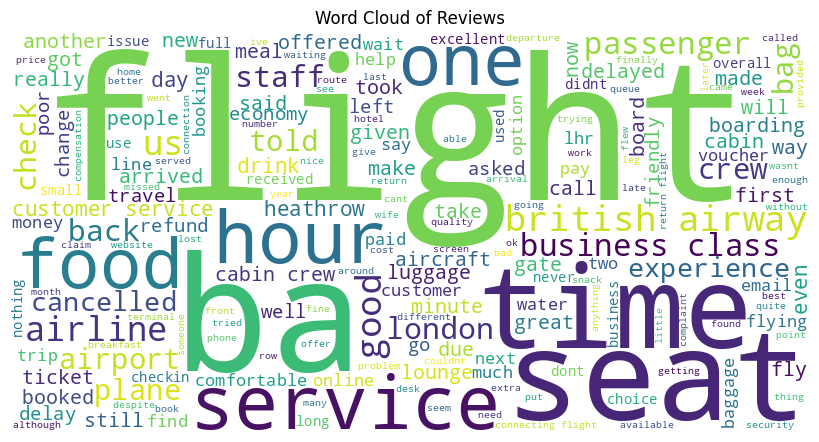

In [11]:
# Visual Insight of the reviews
from wordcloud import WordCloud
import matplotlib.pyplot as plt

#combine all reviews into one big string

text = ''.join(df['reviews'].astype(str))

# Create a word cloud object

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

# Plot the word cloud

plt.figure(figsize=(8, 8), facecolor=None)
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Word Cloud of Reviews")
plt.tight_layout(pad=0)
plt.show()

In [12]:
!pip install vadersentiment

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 2.5 MB/s eta 0:00:00


In [15]:
#Sentiment Analysis
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

#initialyse analyzer

analyzer = SentimentIntensityAnalyzer()

#create a funtion to get sentiment

def get_sentiment(text):
    sentiment = analyzer.polarity_scores(text)

    if sentiment['compound'] >= 0.05:
        return 'positive'
    elif sentiment['compound'] <= -0.05:
        return 'negative'
    else:
        return 'neutral'

df['sentiment'] = df['reviews'].apply(get_sentiment)

#view the distribution

print(df['sentiment'].value_counts())

sentiment
negative    525
positive    457
neutral      18
Name: count, dtype: int64


In [16]:
df['sentiment'].head()

,sentiment
0,negative
1,positive
2,positive
3,positive
4,negative


In [18]:
# Machine Learning

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

X = df['reviews']
y = df['sentiment']

# convert text to numbers
vectorizer = TfidfVectorizer(stop_words = 'english')
X = vectorizer.fit_transform(X)

# split into train and test sets

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

#Train Model
model = LogisticRegression()
model.fit(X_train, y_train)

#Evaluate Model
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    negative       0.82      0.88      0.85       109
     neutral       0.00      0.00      0.00         2
    positive       0.83      0.78      0.80        89

    accuracy                           0.82       200
   macro avg       0.55      0.55      0.55       200
weighted avg       0.82      0.82      0.82       200



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
